In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.io import loadmat
from scipy.optimize import linprog

In [21]:
ev = pd.read_csv("../data/raw/ev_sessions.csv")

load_year = loadmat("../data/raw/load_yearly.mat")["load_all_year"].flatten()
pv_factor = loadmat("../data/raw/PV_production_yearly.mat")["zeta_PV"].flatten()
price_year = loadmat("../data/raw/prices_yearly.mat")["prices_all_year"].flatten()

In [22]:
S_PV_opt = 588.77
E_BESS_opt = 403.43
P_BESS_opt = 103.25

SOC_min = (1 - 0.85) * E_BESS_opt
SOC_max = E_BESS_opt
SOC_initial = 0.5 * E_BESS_opt

eta_ch = 0.9
eta_dch = 0.9

In [17]:
# ==========================================================
# Flexible EV day-ahead scheduling function
#
# Same model as before, but now peak_penalty is an input.
#
# This allows two cases:
# 1) Energy-cost focused:
#       peak_penalty = 4/30
#
# 2) Peak-aware:
#       peak_penalty = 4.0
# ==========================================================

def solve_flexible_ev_day_ahead(
    day_number,
    peak_penalty=4.0 / 30.0
):

    N = 24
    dt = 1.0
    P_EV_max = 7.0

    ev_day = ev[ev["day"] == day_number].copy()

    ev_opt = ev_day[
        ev_day["energy_kwh"] > 0
    ].copy().reset_index(drop=True)

    n_ev = len(ev_opt)

    building_load = load_year[(day_number - 1) * 24 : day_number * 24]
    pv_day = S_PV_opt * pv_factor[(day_number - 1) * 24 : day_number * 24]
    price_day = price_year[(day_number - 1) * 24 : day_number * 24]

    p_E_plus = 1.1 * price_day + 0.05
    p_E_minus = 0.9 * price_day - 0.01

    idx_ev_start = 0
    idx_ch_start = idx_ev_start + n_ev * N
    idx_dch_start = idx_ch_start + N
    idx_soc_start = idx_dch_start + N
    idx_grid_import_start = idx_soc_start + (N + 1)
    idx_grid_export_start = idx_grid_import_start + N
    idx_peak = idx_grid_export_start + N

    n_vars = idx_peak + 1

    c = np.zeros(n_vars)

    for h in range(N):
        c[idx_grid_import_start + h] = p_E_plus[h]
        c[idx_grid_export_start + h] = -p_E_minus[h]

    c[idx_peak] = peak_penalty

    A_eq = []
    b_eq = []

    # Power balance
    for h in range(N):

        row = np.zeros(n_vars)

        for i in range(n_ev):
            row[idx_ev_start + i * N + h] = 1.0

        row[idx_ch_start + h] = 1.0
        row[idx_dch_start + h] = -1.0
        row[idx_grid_import_start + h] = -1.0
        row[idx_grid_export_start + h] = 1.0

        A_eq.append(row)
        b_eq.append(pv_day[h] - building_load[h])

    # EV energy constraints
    for i in range(n_ev):

        row = np.zeros(n_vars)

        for h in range(N):
            row[idx_ev_start + i * N + h] = dt

        A_eq.append(row)
        b_eq.append(ev_opt.loc[i, "energy_kwh"])

    # Battery dynamics
    for h in range(N):

        row = np.zeros(n_vars)

        row[idx_soc_start + h + 1] = 1.0
        row[idx_soc_start + h] = -1.0
        row[idx_ch_start + h] = -eta_ch * dt
        row[idx_dch_start + h] = dt / eta_dch

        A_eq.append(row)
        b_eq.append(0.0)

    # Initial SOC
    row = np.zeros(n_vars)
    row[idx_soc_start] = 1.0
    A_eq.append(row)
    b_eq.append(SOC_initial)

    # Terminal SOC
    row = np.zeros(n_vars)
    row[idx_soc_start + N] = 1.0
    A_eq.append(row)
    b_eq.append(SOC_initial)

    A_eq = np.array(A_eq)
    b_eq = np.array(b_eq)

    A_ub = []
    b_ub = []

    # Peak constraint
    for h in range(N):

        row = np.zeros(n_vars)

        row[idx_grid_import_start + h] = 1.0
        row[idx_peak] = -1.0

        A_ub.append(row)
        b_ub.append(0.0)

    A_ub = np.array(A_ub)
    b_ub = np.array(b_ub)

    bounds = []

    # EV charging bounds
    for i in range(n_ev):

        connection_minute = ev_opt.loc[i, "connection_minute"]
        disconnection_minute = ev_opt.loc[i, "disconnection_minute"]

        for h in range(N):

            hour_start = h * 60
            hour_end = (h + 1) * 60

            overlap_min = max(
                0,
                min(disconnection_minute, hour_end)
                - max(connection_minute, hour_start)
            )

            if overlap_min > 0:
                bounds.append((0, P_EV_max))
            else:
                bounds.append((0, 0))

    for h in range(N):
        bounds.append((0, P_BESS_opt))

    for h in range(N):
        bounds.append((0, P_BESS_opt))

    for h in range(N + 1):
        bounds.append((SOC_min, SOC_max))

    for h in range(N):
        bounds.append((0, None))

    for h in range(N):
        bounds.append((0, None))

    bounds.append((0, None))

    result = linprog(
        c=c,
        A_eq=A_eq,
        b_eq=b_eq,
        A_ub=A_ub,
        b_ub=b_ub,
        bounds=bounds,
        method="highs"
    )

    if not result.success:
        return {
            "success": False,
            "message": result.message
        }

    x = result.x

    P_EV = x[idx_ev_start:idx_ch_start].reshape(n_ev, N)

    return {
        "success": True,
        "cost_EUR": result.fun,
        "ev_profile": P_EV.sum(axis=0),
        "building_load": building_load,
        "pv_day": pv_day,
        "P_ch": x[idx_ch_start:idx_dch_start],
        "P_dch": x[idx_dch_start:idx_soc_start],
        "SOC": x[idx_soc_start:idx_grid_import_start],
        "grid_import": x[idx_grid_import_start:idx_grid_export_start],
        "grid_export": x[idx_grid_export_start:idx_peak],
        "peak_grid_import": x[idx_peak],
        "price_day": price_day
    }

In [25]:
# ==========================================================
# OSOPSS-style day-ahead scheduling with fixed load
#
# Used for ASAP baseline comparison.
#
# peak_penalty:
# - 4/30  = daily equivalent of monthly peak price
# - 4.0   = stronger peak-aware operation
# ==========================================================

def solve_osopss_daily_fixed_load(
    day_number,
    extra_load=None,
    peak_penalty=4.0 / 30.0
):

    N = 24
    dt = 1.0

    if extra_load is None:
        extra_load = np.zeros(N)

    load_day = load_year[(day_number - 1) * 24 : day_number * 24]
    total_load = load_day + extra_load

    pv_day = S_PV_opt * pv_factor[(day_number - 1) * 24 : day_number * 24]
    price_day = price_year[(day_number - 1) * 24 : day_number * 24]

    p_E_plus = 1.1 * price_day + 0.05
    p_E_minus = 0.9 * price_day - 0.01

    p_pp_daily = peak_penalty

    idx_ch = 0
    idx_dch = idx_ch + N
    idx_soc = idx_dch + N
    idx_imp = idx_soc + N + 1
    idx_exp = idx_imp + N
    idx_peak = idx_exp + N

    n_vars_fixed = idx_peak + 1

    c_fixed = np.zeros(n_vars_fixed)

    for h in range(N):
        c_fixed[idx_imp + h] = p_E_plus[h]
        c_fixed[idx_exp + h] = -p_E_minus[h]

    c_fixed[idx_peak] = p_pp_daily

    A_eq_fixed = []
    b_eq_fixed = []

    # Power balance
    for h in range(N):

        row = np.zeros(n_vars_fixed)

        row[idx_ch + h] = 1
        row[idx_dch + h] = -1
        row[idx_imp + h] = -1
        row[idx_exp + h] = 1

        A_eq_fixed.append(row)
        b_eq_fixed.append(pv_day[h] - total_load[h])

    # Battery dynamics
    for h in range(N):

        row = np.zeros(n_vars_fixed)

        row[idx_soc + h + 1] = 1
        row[idx_soc + h] = -1
        row[idx_ch + h] = -eta_ch * dt
        row[idx_dch + h] = dt / eta_dch

        A_eq_fixed.append(row)
        b_eq_fixed.append(0)

    # Initial SOC
    row = np.zeros(n_vars_fixed)
    row[idx_soc] = 1
    A_eq_fixed.append(row)
    b_eq_fixed.append(SOC_initial)

    # Terminal SOC
    row = np.zeros(n_vars_fixed)
    row[idx_soc + N] = 1
    A_eq_fixed.append(row)
    b_eq_fixed.append(SOC_initial)

    A_eq_fixed = np.array(A_eq_fixed)
    b_eq_fixed = np.array(b_eq_fixed)

    A_ub_fixed = []
    b_ub_fixed = []

    # Peak constraint
    for h in range(N):

        row = np.zeros(n_vars_fixed)

        row[idx_imp + h] = 1
        row[idx_peak] = -1

        A_ub_fixed.append(row)
        b_ub_fixed.append(0)

    A_ub_fixed = np.array(A_ub_fixed)
    b_ub_fixed = np.array(b_ub_fixed)

    bounds_fixed = []

    for h in range(N):
        bounds_fixed.append((0, P_BESS_opt))

    for h in range(N):
        bounds_fixed.append((0, P_BESS_opt))

    for h in range(N + 1):
        bounds_fixed.append((SOC_min, SOC_max))

    for h in range(N):
        bounds_fixed.append((0, None))

    for h in range(N):
        bounds_fixed.append((0, None))

    bounds_fixed.append((0, None))

    fixed_result = linprog(
        c=c_fixed,
        A_eq=A_eq_fixed,
        b_eq=b_eq_fixed,
        A_ub=A_ub_fixed,
        b_ub=b_ub_fixed,
        bounds=bounds_fixed,
        method="highs"
    )

    if not fixed_result.success:
        return {
            "success": False,
            "message": fixed_result.message
        }

    x_fixed = fixed_result.x

    return {
        "success": True,
        "cost_EUR": fixed_result.fun,
        "load_day": load_day,
        "extra_load": extra_load,
        "total_load": total_load,
        "pv_day": pv_day,
        "P_ch": x_fixed[idx_ch:idx_dch],
        "P_dch": x_fixed[idx_dch:idx_soc],
        "SOC": x_fixed[idx_soc:idx_imp],
        "grid_import": x_fixed[idx_imp:idx_exp],
        "grid_export": x_fixed[idx_exp:idx_peak],
        "peak_grid_import": x_fixed[idx_peak],
        "price_day": price_day
    }

In [26]:
# ==========================================================
# Compare ASAP, energy-cost flexible, and peak-aware flexible
# ==========================================================

DAY = 20

ev_day = ev[ev["day"] == DAY].copy()
ev_asap = build_asap_profile(ev_day, P_EV_max=7.0)

# Case 1: ASAP fixed load
asap_osopss = solve_osopss_daily_fixed_load(
    DAY,
    extra_load=ev_asap,
    peak_penalty=4.0 / 30.0
)

# Case 2: flexible EV, energy-cost focused
flex_energy = solve_flexible_ev_day_ahead(
    DAY,
    peak_penalty=4.0 / 30.0
)

# Case 3: flexible EV, peak-aware
flex_peak = solve_flexible_ev_day_ahead(
    DAY,
    peak_penalty=4.0
)

print("========== DAY", DAY, "COMPARISON ==========")

print("\nASAP cost [EUR]:", asap_osopss["cost_EUR"])
print("Energy-flex cost [EUR]:", flex_energy["cost_EUR"])
print("Peak-flex cost [EUR]:", flex_peak["cost_EUR"])

print("\nASAP grid import [kWh]:", asap_osopss["grid_import"].sum())
print("Energy-flex grid import [kWh]:", flex_energy["grid_import"].sum())
print("Peak-flex grid import [kWh]:", flex_peak["grid_import"].sum())

print("\nASAP peak [kW]:", asap_osopss["peak_grid_import"])
print("Energy-flex peak [kW]:", flex_energy["peak_grid_import"])
print("Peak-flex peak [kW]:", flex_peak["peak_grid_import"])

print("\nASAP EV peak [kW]:", ev_asap.max())
print("Energy-flex EV peak [kW]:", flex_energy["ev_profile"].max())
print("Peak-flex EV peak [kW]:", flex_peak["ev_profile"].max())

========== DAY 20 COMPARISON ==========

ASAP cost [EUR]: 200.08717930278502
Energy-flex cost [EUR]: 198.79256884466668
Peak-flex cost [EUR]: 439.7079239658775

ASAP grid import [kWh]: 1438.6337653107344
Energy-flex grid import [kWh]: 1435.1690455800413
Peak-flex grid import [kWh]: 1443.3426280700858

ASAP peak [kW]: 73.7597187435
Energy-flex peak [kW]: 79.69524299785269
Peak-flex peak [kW]: 61.732897409871065

ASAP EV peak [kW]: 68.5
Energy-flex EV peak [kW]: 66.18552425435269
Peak-flex EV peak [kW]: 65.10282713787106


In [3]:
scenario_flexible_df = pd.read_csv(
    "../results/tables/notebook15_OSOPSS_flexible_EV_scenario_comparison.csv"
)

scenario_flexible_df.round(2)

,Scenario,Day,EV_energy_kWh,ASAP_cost_EUR,Flexible_cost_EUR,Cost_saving_EUR,ASAP_grid_import_kWh,Flexible_grid_import_kWh,Grid_import_reduction_kWh,ASAP_grid_export_kWh,Flexible_grid_export_kWh,Grid_export_change_kWh,ASAP_peak_grid_kW,Flexible_peak_grid_kW,Peak_grid_reduction_kW,ASAP_peak_EV_kW,Flexible_peak_EV_kW
0,Low,106,37.0,-67.84,-70.11,2.27,155.54,155.54,0.00,1725.48,1725.48,0.0,15.61,15.61,0.00,11.8,27.00
1,Medium,20,303.0,200.09,198.79,1.29,1438.63,1435.17,3.46,0.00,0.00,0.0,73.76,79.70,-5.94,68.5,66.19
2,High,95,509.0,-37.22,-41.70,4.48,128.91,128.91,0.00,1399.11,1399.11,0.0,20.95,20.95,0.00,127.9,181.95


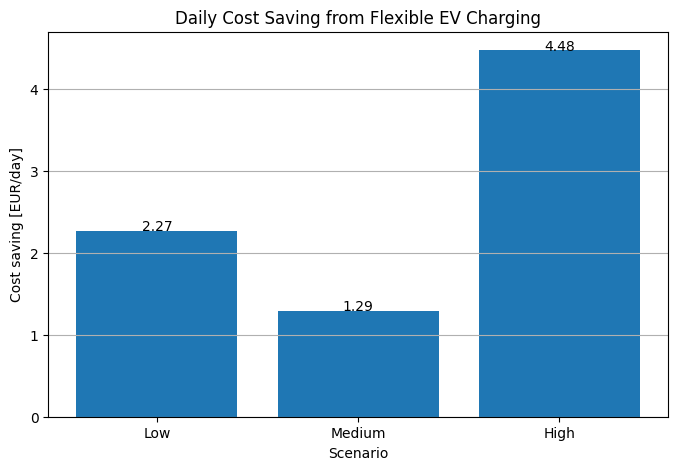

In [4]:
plt.figure(figsize=(8,5))

plt.bar(
    scenario_flexible_df["Scenario"],
    scenario_flexible_df["Cost_saving_EUR"]
)

plt.ylabel("Cost saving [EUR/day]")
plt.xlabel("Scenario")
plt.title("Daily Cost Saving from Flexible EV Charging")

for i, v in enumerate(scenario_flexible_df["Cost_saving_EUR"]):
    plt.text(i, v, f"{v:.2f}", ha="center")

plt.grid(axis="y")
plt.show()

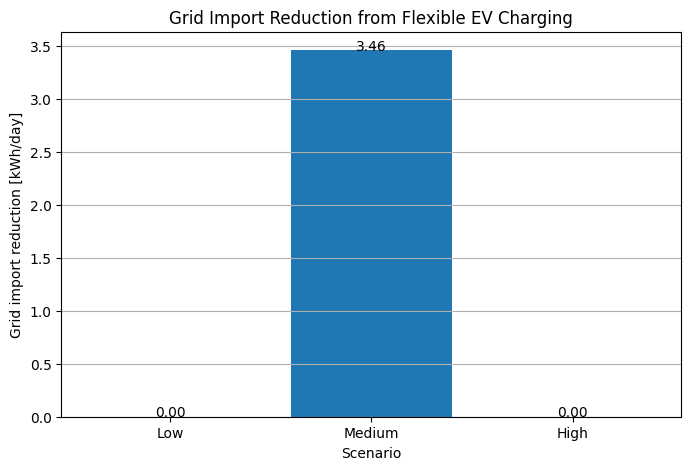

In [5]:
plt.figure(figsize=(8,5))

plt.bar(
    scenario_flexible_df["Scenario"],
    scenario_flexible_df["Grid_import_reduction_kWh"]
)

plt.ylabel("Grid import reduction [kWh/day]")
plt.xlabel("Scenario")
plt.title("Grid Import Reduction from Flexible EV Charging")

for i, v in enumerate(scenario_flexible_df["Grid_import_reduction_kWh"]):
    plt.text(i, v, f"{v:.2f}", ha="center")

plt.grid(axis="y")
plt.show()

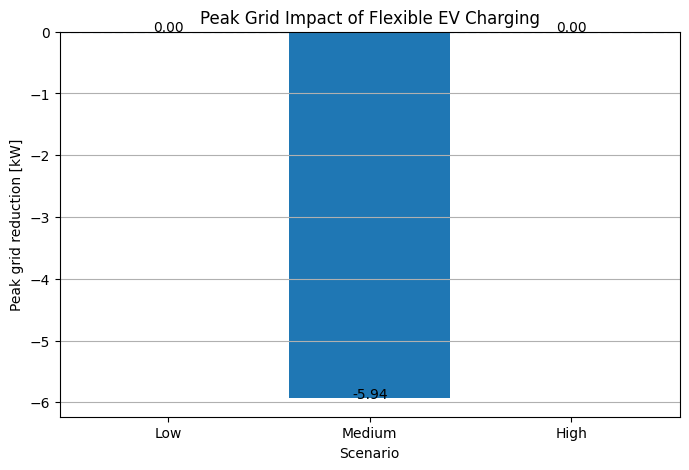

In [6]:
plt.figure(figsize=(8,5))

plt.bar(
    scenario_flexible_df["Scenario"],
    scenario_flexible_df["Peak_grid_reduction_kW"]
)

plt.axhline(0, linestyle="--")

plt.ylabel("Peak grid reduction [kW]")
plt.xlabel("Scenario")
plt.title("Peak Grid Impact of Flexible EV Charging")

for i, v in enumerate(scenario_flexible_df["Peak_grid_reduction_kW"]):
    plt.text(i, v, f"{v:.2f}", ha="center")

plt.grid(axis="y")
plt.show()

In [7]:
summary = scenario_flexible_df[
    [
        "Scenario",
        "EV_energy_kWh",
        "Cost_saving_EUR",
        "Grid_import_reduction_kWh",
        "Peak_grid_reduction_kW"
    ]
].copy()

summary.round(2)

,Scenario,EV_energy_kWh,Cost_saving_EUR,Grid_import_reduction_kWh,Peak_grid_reduction_kW
0,Low,37.0,2.27,0.00,0.00
1,Medium,303.0,1.29,3.46,-5.94
2,High,509.0,4.48,0.00,0.00


In [8]:
summary = scenario_flexible_df[
    [
        "Scenario",
        "EV_energy_kWh",
        "Cost_saving_EUR",
        "Grid_import_reduction_kWh",
        "Peak_grid_reduction_kW"
    ]
].copy()

summary.round(2)

,Scenario,EV_energy_kWh,Cost_saving_EUR,Grid_import_reduction_kWh,Peak_grid_reduction_kW
0,Low,37.0,2.27,0.00,0.00
1,Medium,303.0,1.29,3.46,-5.94
2,High,509.0,4.48,0.00,0.00


In [11]:
def build_asap_profile(ev_day, P_EV_max=7.0):

    N = 24
    ev_asap = np.zeros(N)

    for _, car in ev_day.iterrows():

        energy_remaining = car["energy_kwh"]

        start_min = int(car["connection_minute"])
        end_min = int(car["disconnection_minute"])

        for h in range(N):

            hour_start = h * 60
            hour_end = (h + 1) * 60

            overlap_min = max(
                0,
                min(end_min, hour_end)
                - max(start_min, hour_start)
            )

            if overlap_min > 0 and energy_remaining > 0:

                energy_this_hour = (
                    P_EV_max
                    * overlap_min
                    / 60
                )

                energy_this_hour = min(
                    energy_this_hour,
                    energy_remaining
                )

                ev_asap[h] += energy_this_hour

                energy_remaining -= energy_this_hour

    return ev_asap

In [12]:
# ==========================================================
# Build full-year ASAP EV charging profile
# ==========================================================

N_year = 8760
ev_asap_year = np.zeros(N_year)

for day in range(1, 366):

    ev_day = ev[
        ev["day"] == day
    ].copy()

    ev_asap_day = build_asap_profile(
        ev_day,
        P_EV_max=7.0
    )

    start = (day - 1) * 24
    end = day * 24

    ev_asap_year[start:end] = ev_asap_day

print("Yearly ASAP EV energy [kWh]:", ev_asap_year.sum())
print("Expected EV energy [kWh]:", ev["energy_kwh"].sum())
print("Peak ASAP EV power [kW]:", ev_asap_year.max())

Yearly ASAP EV energy [kWh]: 95504.33333333333
Expected EV energy [kWh]: 95663.0
Peak ASAP EV power [kW]: 127.90000000000002


Run yearly ASAP

In [28]:
N_year = 8760
ev_asap_year = np.zeros(N_year)

for day in range(1, 366):
    ev_day = ev[ev["day"] == day].copy()
    ev_asap_day = build_asap_profile(ev_day, P_EV_max=7.0)

    start = (day - 1) * 24
    end = day * 24
    ev_asap_year[start:end] = ev_asap_day

print("Yearly ASAP EV energy [kWh]:", ev_asap_year.sum())
print("Expected EV energy [kWh]:", ev["energy_kwh"].sum())
print("Peak ASAP EV power [kW]:", ev_asap_year.max())

Yearly ASAP EV energy [kWh]: 95504.33333333333
Expected EV energy [kWh]: 95663.0
Peak ASAP EV power [kW]: 127.90000000000002


Run yearly flexible

In [29]:
ev_flexible_year = np.zeros(N_year)
failed_days = []

for day in range(1, 366):

    if day % 25 == 0:
        print("Solving day:", day)

    result_day = solve_flexible_ev_day_ahead(
        day,
        peak_penalty=4.0 / 30.0
    )

    if result_day["success"]:
        start = (day - 1) * 24
        end = day * 24
        ev_flexible_year[start:end] = result_day["ev_profile"]
    else:
        failed_days.append(day)

print("Failed days:", failed_days)
print("Yearly flexible EV energy [kWh]:", ev_flexible_year.sum())
print("Peak flexible EV power [kW]:", ev_flexible_year.max())

Solving day: 25
Solving day: 50
Solving day: 75
Solving day: 100
Solving day: 125
Solving day: 150
Solving day: 175
Solving day: 200
Solving day: 225
Solving day: 250
Solving day: 275
Solving day: 300
Solving day: 325
Solving day: 350
Failed days: [5, 126, 201, 202, 247, 248, 251, 308, 325]
Yearly flexible EV energy [kWh]: 92849.0
Peak flexible EV power [kW]: 206.42068448549992


For now, fix it by filling failed days with ASAP charging:

In [30]:
# ==========================================================
# Fill failed flexible days with ASAP profile
#
# This keeps yearly energy consistent while still using
# optimized flexible charging for successful days.
# ==========================================================

for day in failed_days:

    ev_day = ev[ev["day"] == day].copy()

    ev_asap_day = build_asap_profile(
        ev_day,
        P_EV_max=7.0
    )

    start = (day - 1) * 24
    end = day * 24

    ev_flexible_year[start:end] = ev_asap_day

print("Corrected yearly flexible EV energy [kWh]:", ev_flexible_year.sum())
print("ASAP yearly EV energy [kWh]:", ev_asap_year.sum())
print("Peak corrected flexible EV power [kW]:", ev_flexible_year.max())

Corrected yearly flexible EV energy [kWh]: 95574.61666666667
ASAP yearly EV energy [kWh]: 95504.33333333333
Peak corrected flexible EV power [kW]: 206.42068448549992


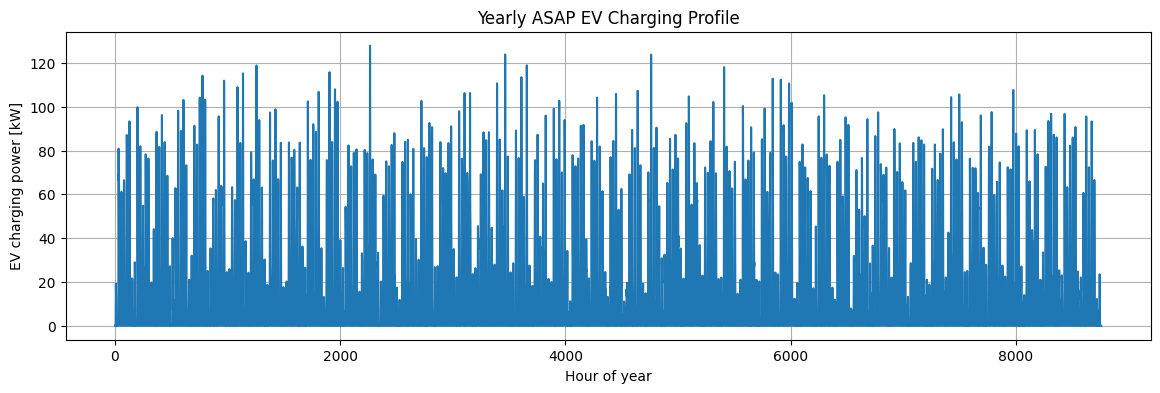

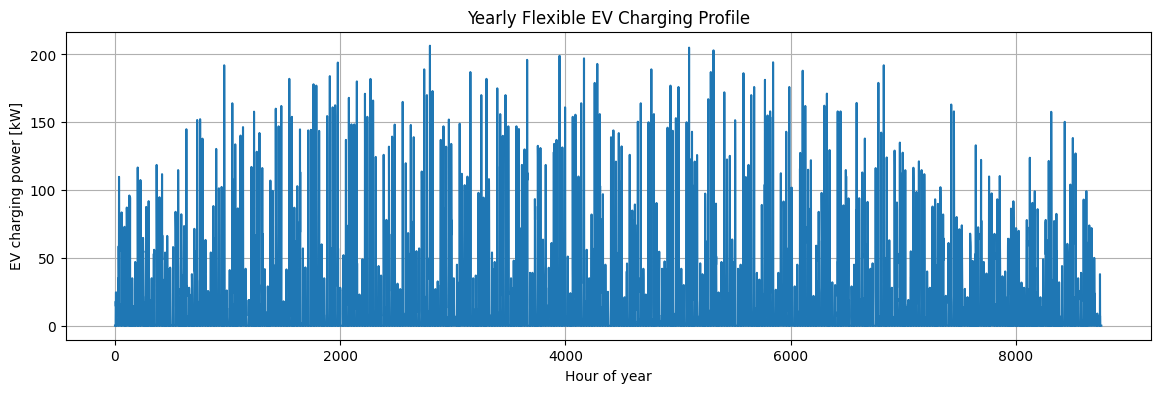

In [31]:
hours = np.arange(N_year)

plt.figure(figsize=(14,4))
plt.plot(ev_asap_year)

plt.xlabel("Hour of year")
plt.ylabel("EV charging power [kW]")
plt.title("Yearly ASAP EV Charging Profile")
plt.grid()

plt.show()


plt.figure(figsize=(14,4))
plt.plot(ev_flexible_year)

plt.xlabel("Hour of year")
plt.ylabel("EV charging power [kW]")
plt.title("Yearly Flexible EV Charging Profile")
plt.grid()

plt.show()